In [45]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [46]:
import math

import matplotlib.pyplot as plt              # For plotting
import seaborn as sns                        # For styling plots
import torch                                 # Overall PyTorch import
import torch.nn as nn                        # For specifying neural networks
import torch.nn.functional as F              # For common functions
import torch.optim as optim                  # For optimizizing model parameters
import torchvision.datasets as datasets      # To download data
import torchvision.transforms as transforms  # For pre-processing data

sns.set()
torch.manual_seed(0)

In [47]:
INPUT_SIZE    = 3 * 32 * 32   # An image has 32 x 32 pixels each with Red/Green/Blue values.
NUM_CLASSES   = 10            # The number of output classes. In this case, from 0 to 9
BATCH_SIZE    = 100           # The size of input data took for one iteration of an epoch
SAMPLE_DATA   = False         # A flag that controls if we should make the dataset smaller
                              # for faster training time when developing a solution.
                              # ⚠️ ENSURE THIS FLAG IS FALSE AND YOU RERUN ALL CELLS BEFORE YOU SUBMIT

In [48]:
transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
valset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

if SAMPLE_DATA:  # Make sure this is False and you rerun all cells before you submit!
    # Only grab a subset of the data to speed up training time while developing a solution
    trainset, _ = torch.utils.data.random_split(trainset, [BATCH_SIZE * 10, len(trainset) - BATCH_SIZE * 10])
    valset, _ = torch.utils.data.random_split(valset, [BATCH_SIZE * 10, len(valset) - BATCH_SIZE * 10])


train_loader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = torch.utils.data.DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [49]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [50]:
def train(net, train_loader, val_loader,
          num_epochs, learning_rate,
          compute_accs=False):
    """
    This function trains the given network on the training data for the given number of epochs.
    If compute_accs is true, evaluates the train and val accuracy of the network at the end of
    each epoch.

    Args:
        net: The neural network to train
        train_loader, val_loader: The pytorch dataset loaders for the trainset and valset
        num_epochs: The number of times to loop over the batches in train_loader
        learning_rate: The learning rate for the optimizer
        compute_accs: A bool flag for whether or not this function should compute the train and val
                      accuracies at the end of each epoch. This feature is useful for visualizing
                      how the model is learning, but slows down training time.
    Returns:
        The train and val accuracies if compute_accs is True, None otherwise
    """
    # First initialize the criterion (loss function) and the optimizer
    # (algorithm like gradient descent). Here we use a common loss function for multi-class
    # classification called the Cross Entropy Loss and the popular Adam algorithm.
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate)

    train_accs = []
    val_accs = []
    best_val_acc = 0

    for epoch in range(1, num_epochs + 1):
        batch_num = 1
        for images, labels in train_loader:   # Loop over each batch in train_loader

            # If you are using a GPU, speed up computation by moving values to the GPU

            images = images.to(device)
            labels = labels.to(device)


            optimizer.zero_grad()               # Reset gradient for next computation
            outputs = net(images)               # Forward pass: compute the output class given a image
            loss = criterion(outputs, labels)   # Compute loss: difference between the pred and true
            loss.backward()                     # Backward pass: compute the weight
            optimizer.step()                    # Optimizer: update the weights of hidden nodes

            if batch_num % 100 == 0:  # Print every 100 batches
                print(f'Epoch [{epoch}/{num_epochs}], Step [{batch_num}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')

            batch_num += 1

        if compute_accs:
            train_acc = accuracy(net, train_loader)
            val_acc = accuracy(net, val_loader)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            best_val_acc = max(best_val_acc, val_acc)
            print(f'Epoch [{epoch}/{num_epochs}], Train Accuracy {100 * train_acc:.2f}%, Validation Accuracy {100 * val_acc:.2f}%')
            print(f'Best Validation Accuracy {100 * best_val_acc:.2f}%')

    if compute_accs:
        return train_accs, val_accs, best_val_acc


def accuracy(net, data_loader):
    """
    For a given data_loader, evaluate the model on the dataset and compute its classification
    accuracy.

    Args:
        net: The neural network to train
        data_loader: A dataset loader for some dataset.
    Returns:
        The classificiation accuracy of the model on this dataset.
    """
    correct = 0
    total = 0
    for images, labels in data_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)                           # Make predictions
        _, predicted = torch.max(outputs.data, 1)       # Choose class with highest scores
        total += labels.size(0)                         # Increment the total count
        correct += (predicted == labels).sum().item()   # Increment the correct count

    return correct / total


def plot_history(histories):
    """
    Given a series of training/validation accuracies from training, plots them to visualize learning.

    Args:
        histories: A list of dictionaries storing information about each model trained.
                   Each dictionary should have the keys:
                        * name: The model name
                        * train_accs: A list of train accuracies
                        * val_accs: A list of val accuracies.
    """
    plt.figure(figsize=(16,10))
    epochs = list(range(1, len(histories[0]['train_accs']) + 1))
    for model_history in histories:
      val = plt.plot(epochs, model_history['val_accs'],
                     '--', label=model_history['name'] + ' Validation')
      plt.plot(epochs, model_history['train_accs'], color=val[0].get_color(),
               label=model_history['name'] + ' Train')

    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.xlim([1,max(epochs)])

In [51]:
class NetExample(nn.Module):
    def __init__(self):
        super(NetExample, self).__init__()
        # Define the layers in the __init__ method, and use the layers
        # in the forward method.
        self.lin = nn.Linear(INPUT_SIZE, NUM_CLASSES)

    def forward(self, x):
        x = x.view(-1, INPUT_SIZE) # Flatten the image into a vector
        x = self.lin(x) # Pass the image into a fully connected layer
        return x

In [52]:
class NetA(nn.Module):
    def __init__(self):
        super(NetA, self).__init__()
        self.fc1 = nn.Linear(INPUT_SIZE, 300)
        self.fc2 = nn.Linear(300, NUM_CLASSES)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [53]:
class NetB(nn.Module):
    def __init__(self):
        super(NetB, self).__init__()
        self.fc1 = nn.Linear(INPUT_SIZE, 100)
        self.fc2 = nn.Linear(100, 60)
        self.fc3 = nn.Linear(60, NUM_CLASSES)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten images
        x = F.relu(self.fc1(x))     # first hidden layer
        x = F.relu(self.fc2(x))     # second hidden layer
        x = self.fc3(x)             # output logits
        return x

In [54]:
class NetC(nn.Module):
    def __init__(self):
        super(NetC, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=25, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(25 * 14 * 14, NUM_CLASSES)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [55]:
class NetD(nn.Module):
    def __init__(self):
        super(NetD, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, NUM_CLASSES)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [56]:
class NetE(nn.Module):
    def __init__(self):
        super(NetE, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.bn_fc1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, NUM_CLASSES)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.fc2(x)
        return x

==== Training NetA ====
Epoch [1/10], Step [100/500], Loss: 1.8410
Epoch [1/10], Step [200/500], Loss: 1.5857
Epoch [1/10], Step [300/500], Loss: 1.3770
Epoch [1/10], Step [400/500], Loss: 1.5844
Epoch [1/10], Step [500/500], Loss: 1.3344
Epoch [1/10], Train Accuracy 48.59%, Validation Accuracy 45.68%
Best Validation Accuracy 45.68%
Epoch [2/10], Step [100/500], Loss: 1.4966
Epoch [2/10], Step [200/500], Loss: 1.6076
Epoch [2/10], Step [300/500], Loss: 1.5797
Epoch [2/10], Step [400/500], Loss: 1.3239
Epoch [2/10], Step [500/500], Loss: 1.4066
Epoch [2/10], Train Accuracy 54.59%, Validation Accuracy 49.92%
Best Validation Accuracy 49.92%
Epoch [3/10], Step [100/500], Loss: 1.3634
Epoch [3/10], Step [200/500], Loss: 1.5246
Epoch [3/10], Step [300/500], Loss: 1.2471
Epoch [3/10], Step [400/500], Loss: 1.3813
Epoch [3/10], Step [500/500], Loss: 1.2004
Epoch [3/10], Train Accuracy 57.05%, Validation Accuracy 50.35%
Best Validation Accuracy 50.35%
Epoch [4/10], Step [100/500], Loss: 1.2510


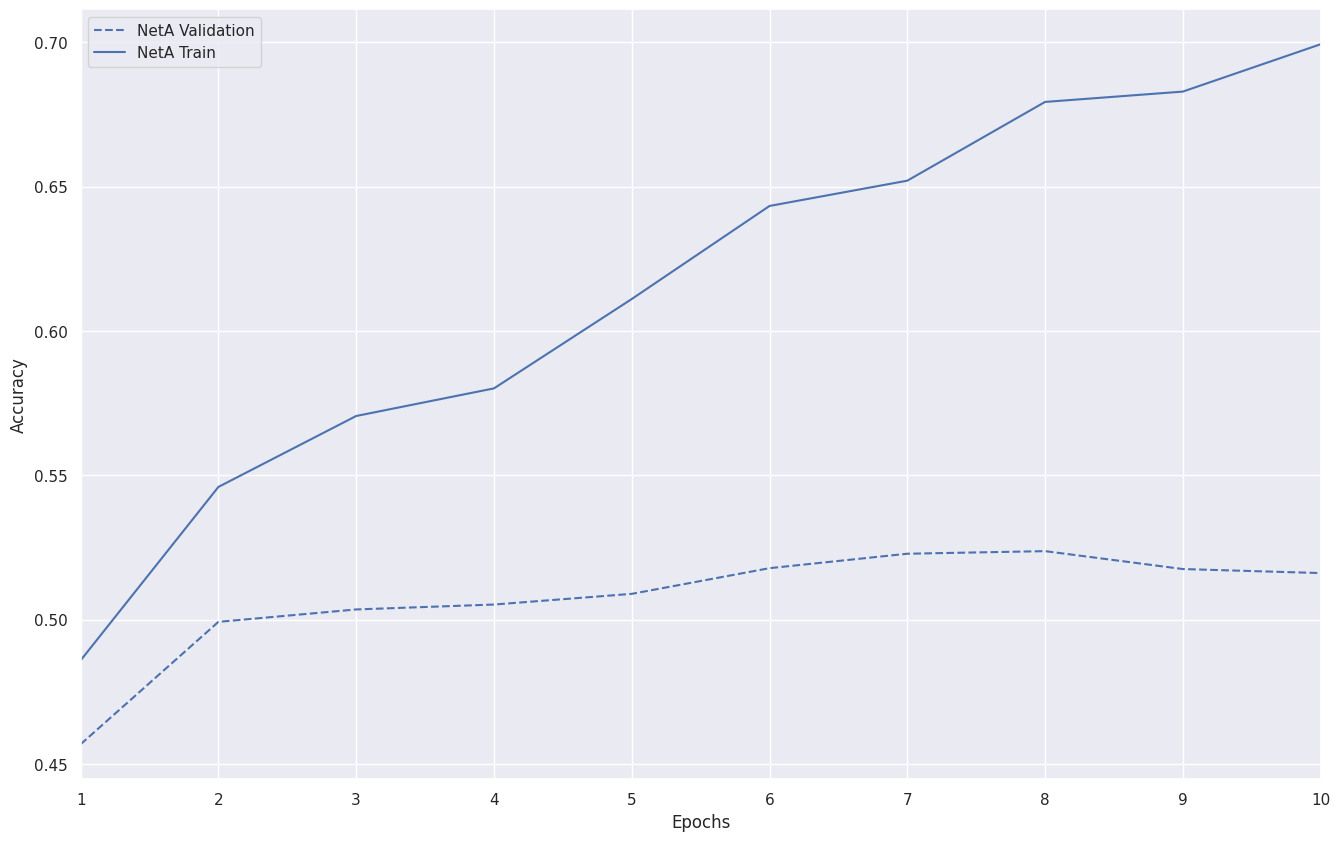

In [57]:
histories_A = []

netA = NetA()
print(f'==== Training NetA ====')
netA.to(device)
train_history_A, val_history_A, _ = train(netA, train_loader, val_loader,
    num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_A.append({
      'name': 'NetA',
      'train_accs': train_history_A,
      'val_accs': val_history_A
})
plot_history(histories_A)

==== Training NetB ====
Epoch [1/10], Step [100/500], Loss: 1.8605
Epoch [1/10], Step [200/500], Loss: 1.6270
Epoch [1/10], Step [300/500], Loss: 1.6380
Epoch [1/10], Step [400/500], Loss: 1.4934
Epoch [1/10], Step [500/500], Loss: 1.4239
Epoch [1/10], Train Accuracy 47.47%, Validation Accuracy 46.21%
Best Validation Accuracy 46.21%
Epoch [2/10], Step [100/500], Loss: 1.5901
Epoch [2/10], Step [200/500], Loss: 1.4287
Epoch [2/10], Step [300/500], Loss: 1.4815
Epoch [2/10], Step [400/500], Loss: 1.6264
Epoch [2/10], Step [500/500], Loss: 1.3128
Epoch [2/10], Train Accuracy 50.70%, Validation Accuracy 48.29%
Best Validation Accuracy 48.29%
Epoch [3/10], Step [100/500], Loss: 1.4099
Epoch [3/10], Step [200/500], Loss: 1.2900
Epoch [3/10], Step [300/500], Loss: 1.3666
Epoch [3/10], Step [400/500], Loss: 1.5059
Epoch [3/10], Step [500/500], Loss: 1.2207
Epoch [3/10], Train Accuracy 54.69%, Validation Accuracy 50.34%
Best Validation Accuracy 50.34%
Epoch [4/10], Step [100/500], Loss: 1.4276


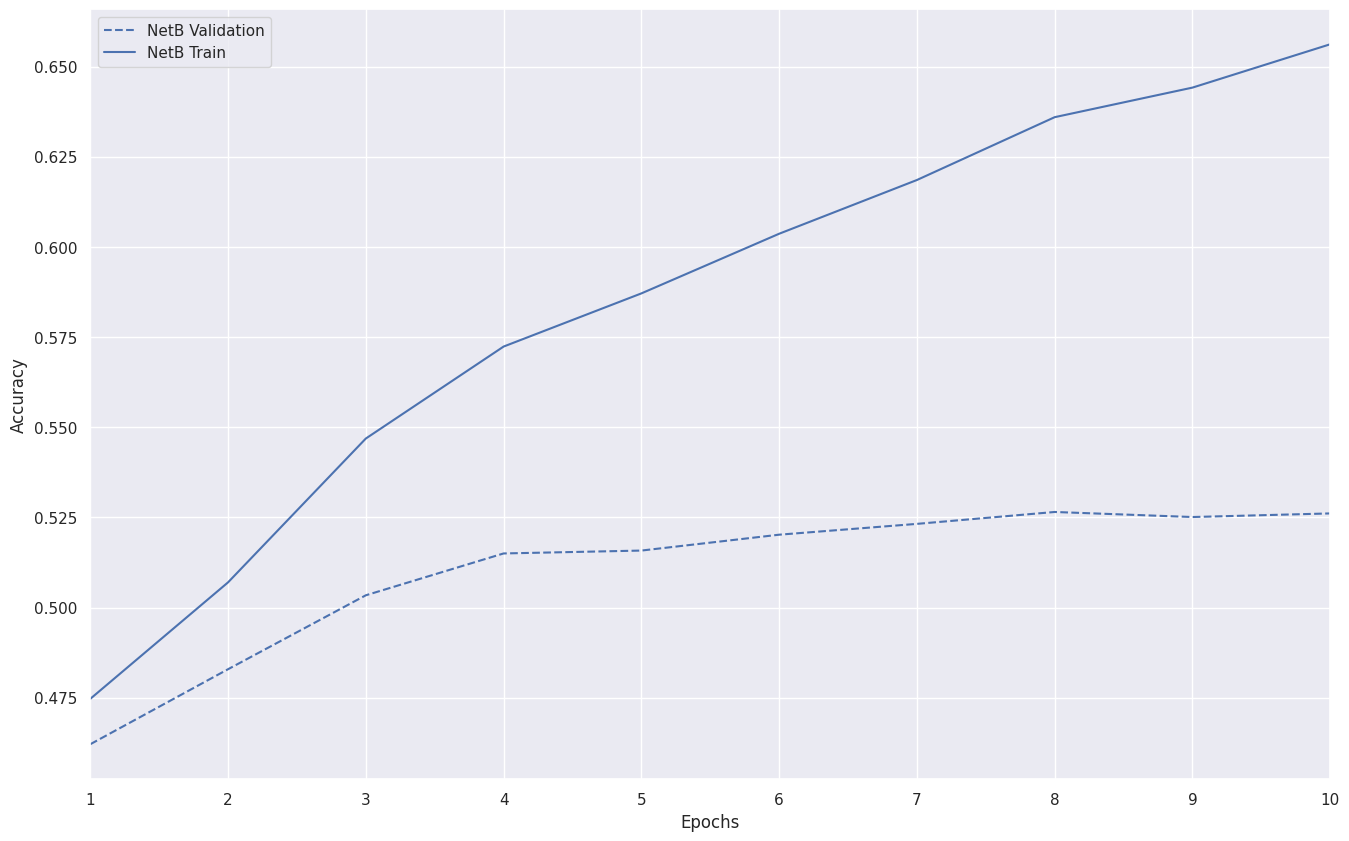

In [58]:
histories_B = []

netB = NetB()
print(f'==== Training NetB ====')
netB.to(device)
train_history_B, val_history_B, _ = train(netB, train_loader, val_loader,
        num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_B.append({
      'name': 'NetB',
      'train_accs': train_history_B,
      'val_accs': val_history_B
})
plot_history(histories_B)

==== Training NetC ====
Epoch [1/10], Step [100/500], Loss: 1.6351
Epoch [1/10], Step [200/500], Loss: 1.3934
Epoch [1/10], Step [300/500], Loss: 1.2396
Epoch [1/10], Step [400/500], Loss: 1.3768
Epoch [1/10], Step [500/500], Loss: 1.2245
Epoch [1/10], Train Accuracy 54.56%, Validation Accuracy 52.51%
Best Validation Accuracy 52.51%
Epoch [2/10], Step [100/500], Loss: 1.3420
Epoch [2/10], Step [200/500], Loss: 1.1264
Epoch [2/10], Step [300/500], Loss: 1.2342
Epoch [2/10], Step [400/500], Loss: 1.2087
Epoch [2/10], Step [500/500], Loss: 0.9454
Epoch [2/10], Train Accuracy 63.06%, Validation Accuracy 59.49%
Best Validation Accuracy 59.49%
Epoch [3/10], Step [100/500], Loss: 1.0232
Epoch [3/10], Step [200/500], Loss: 1.0561
Epoch [3/10], Step [300/500], Loss: 0.9884
Epoch [3/10], Step [400/500], Loss: 0.9925
Epoch [3/10], Step [500/500], Loss: 0.9372
Epoch [3/10], Train Accuracy 66.15%, Validation Accuracy 62.13%
Best Validation Accuracy 62.13%
Epoch [4/10], Step [100/500], Loss: 0.9729


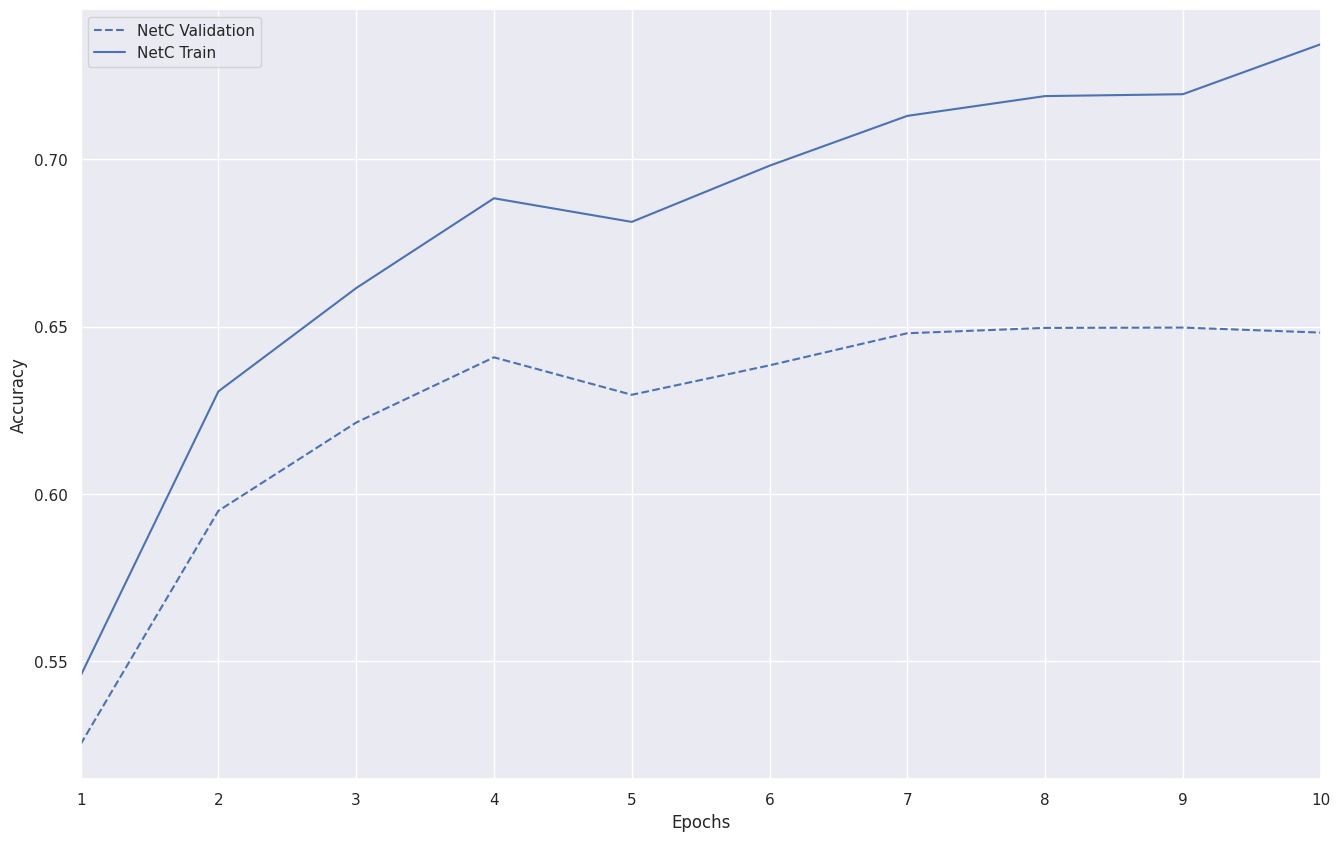

In [59]:
histories_C = []

netC = NetC()
print(f'==== Training NetC ====')
netC.to(device)
train_history_C, val_history_C, _ = train(netC, train_loader, val_loader,
        num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_C.append({
      'name': 'NetC',
      'train_accs': train_history_C,
      'val_accs': val_history_C
})
plot_history(histories_C)

==== Training NetD ====
Epoch [1/10], Step [100/500], Loss: 1.6087
Epoch [1/10], Step [200/500], Loss: 1.6104
Epoch [1/10], Step [300/500], Loss: 1.4338
Epoch [1/10], Step [400/500], Loss: 1.1932
Epoch [1/10], Step [500/500], Loss: 1.3879
Epoch [1/10], Train Accuracy 58.94%, Validation Accuracy 57.87%
Best Validation Accuracy 57.87%
Epoch [2/10], Step [100/500], Loss: 1.1509
Epoch [2/10], Step [200/500], Loss: 0.9384
Epoch [2/10], Step [300/500], Loss: 0.9835
Epoch [2/10], Step [400/500], Loss: 0.9896
Epoch [2/10], Step [500/500], Loss: 0.9853
Epoch [2/10], Train Accuracy 67.38%, Validation Accuracy 64.65%
Best Validation Accuracy 64.65%
Epoch [3/10], Step [100/500], Loss: 0.9172
Epoch [3/10], Step [200/500], Loss: 0.8266
Epoch [3/10], Step [300/500], Loss: 0.9881
Epoch [3/10], Step [400/500], Loss: 0.9424
Epoch [3/10], Step [500/500], Loss: 0.8830
Epoch [3/10], Train Accuracy 71.49%, Validation Accuracy 67.33%
Best Validation Accuracy 67.33%
Epoch [4/10], Step [100/500], Loss: 0.7615


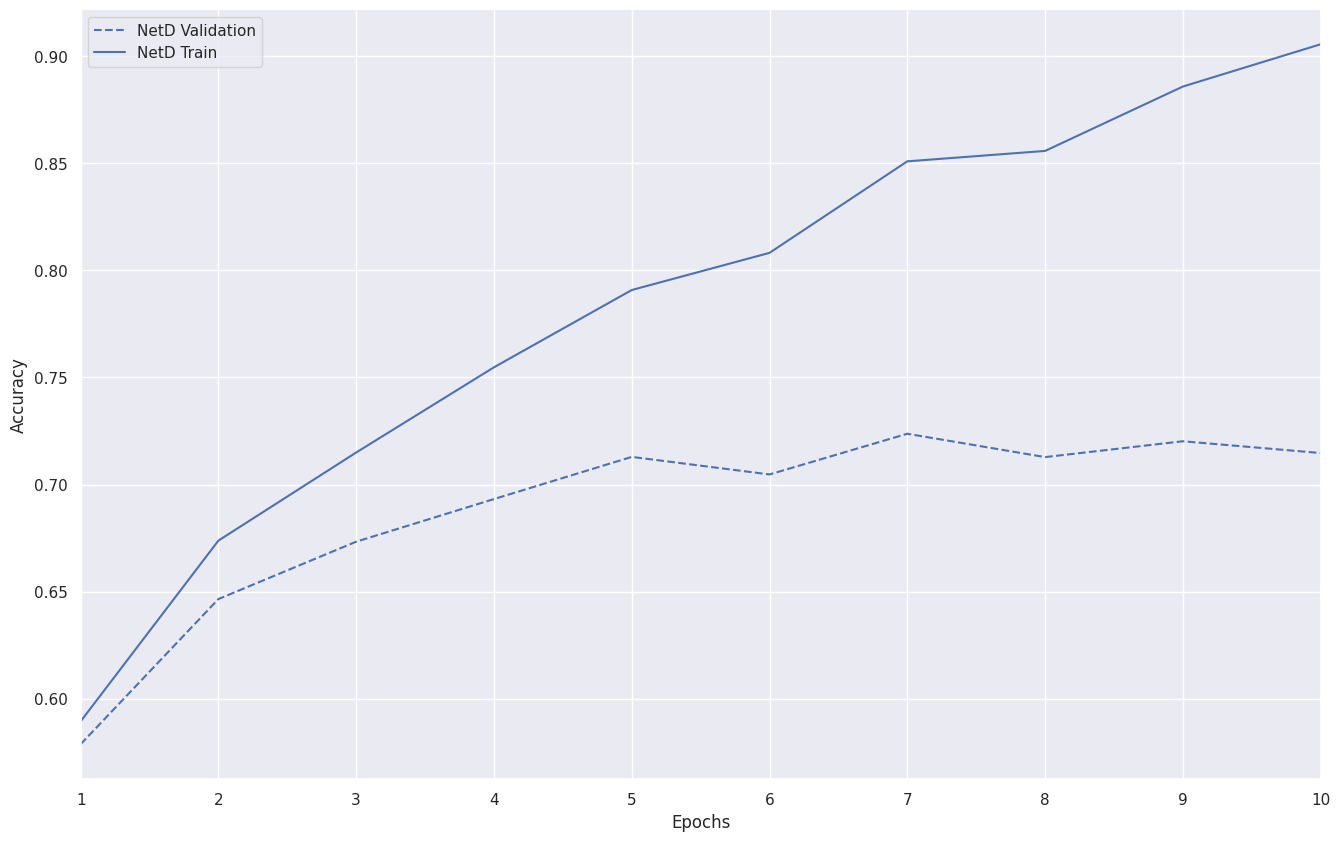

In [60]:
histories_D = []

netD = NetD()
print(f'==== Training NetD ====')
netD.to(device)
train_history_D, val_history_D, _ = train(netD, train_loader, val_loader,
        num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_D.append({
      'name': 'NetD',
      'train_accs': train_history_D,
      'val_accs': val_history_D
})
plot_history(histories_D)

==== Training NetE ====
Epoch [1/10], Step [100/500], Loss: 1.4688
Epoch [1/10], Step [200/500], Loss: 0.8951
Epoch [1/10], Step [300/500], Loss: 1.2863
Epoch [1/10], Step [400/500], Loss: 1.0104
Epoch [1/10], Step [500/500], Loss: 1.0070
Epoch [1/10], Train Accuracy 69.09%, Validation Accuracy 66.19%
Best Validation Accuracy 66.19%
Epoch [2/10], Step [100/500], Loss: 0.9902
Epoch [2/10], Step [200/500], Loss: 0.8473
Epoch [2/10], Step [300/500], Loss: 1.0846
Epoch [2/10], Step [400/500], Loss: 0.8072
Epoch [2/10], Step [500/500], Loss: 0.8627
Epoch [2/10], Train Accuracy 74.15%, Validation Accuracy 69.52%
Best Validation Accuracy 69.52%
Epoch [3/10], Step [100/500], Loss: 0.6382
Epoch [3/10], Step [200/500], Loss: 0.5666
Epoch [3/10], Step [300/500], Loss: 0.7890
Epoch [3/10], Step [400/500], Loss: 0.7877
Epoch [3/10], Step [500/500], Loss: 0.6200
Epoch [3/10], Train Accuracy 80.22%, Validation Accuracy 72.18%
Best Validation Accuracy 72.18%
Epoch [4/10], Step [100/500], Loss: 0.6818


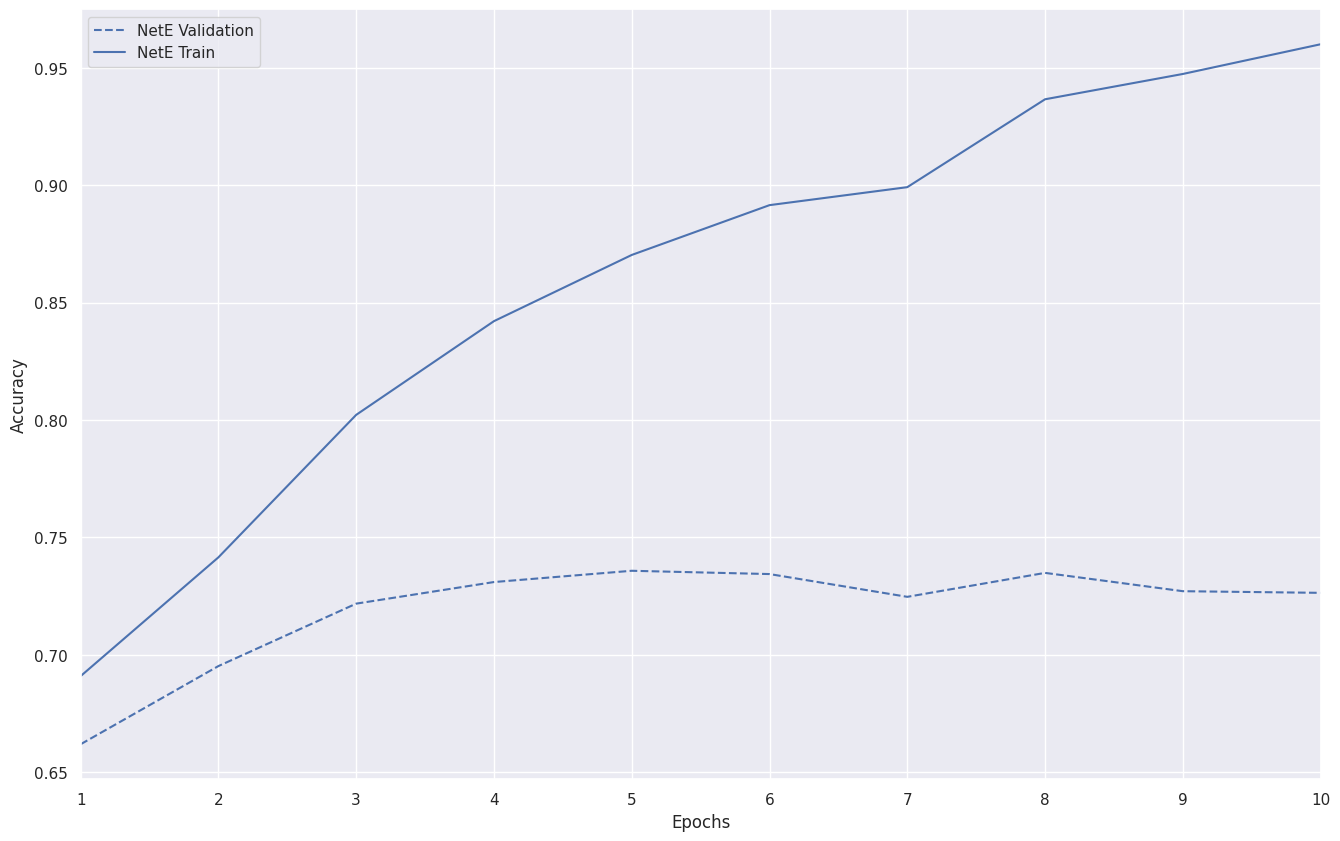

In [61]:
histories_E = []

netE = NetE()
print(f'==== Training NetE ====')
netE.to(device)
train_history_E, val_history_E, _ = train(netE, train_loader, val_loader,
      num_epochs=10, learning_rate=1e-3, compute_accs=True)
histories_E.append({
      'name': 'NetE',
      'train_accs': train_history_E,
      'val_accs': val_history_E
})
plot_history(histories_E)

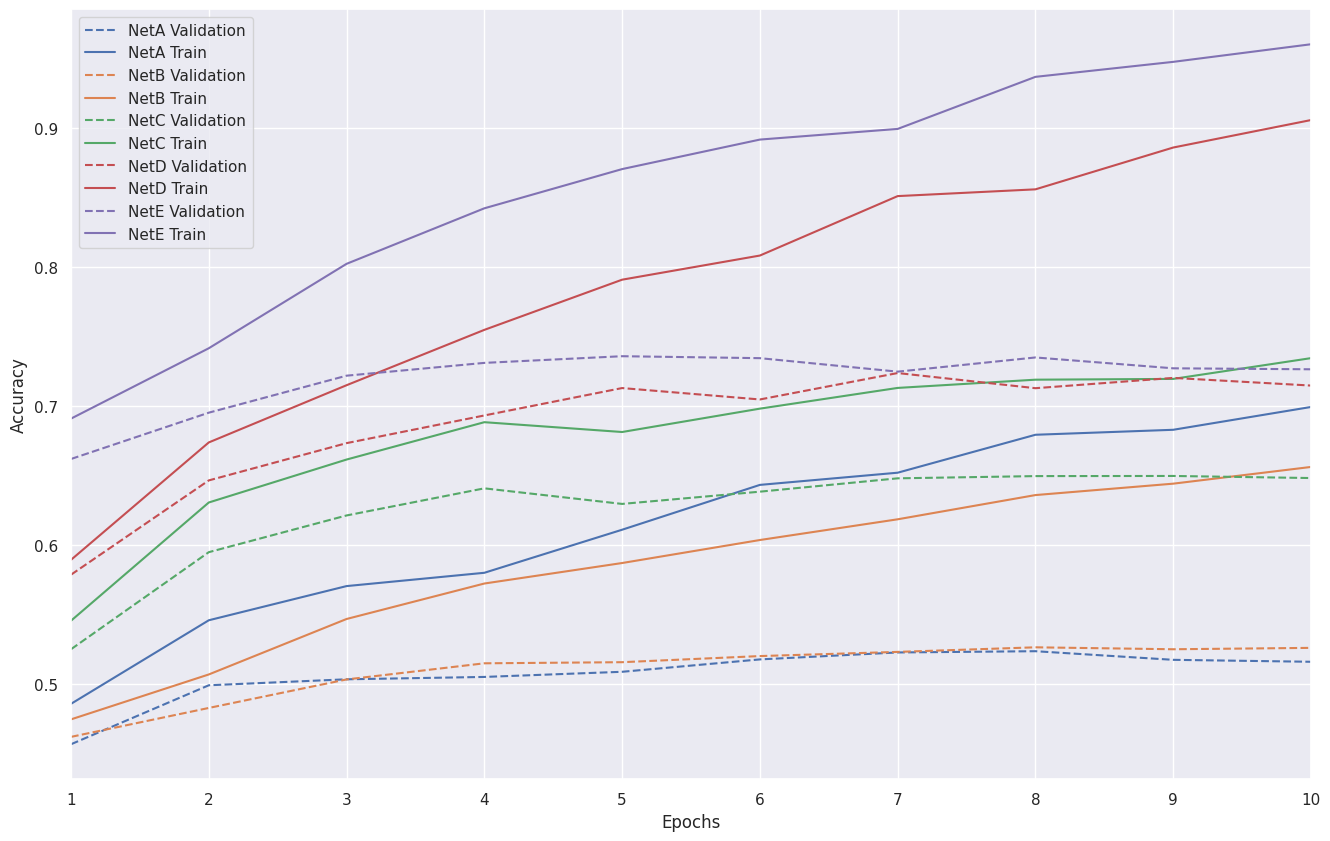

In [62]:
all_histories = histories_A + histories_B + histories_C + histories_D + histories_E
plot_history(all_histories)